In [1]:
import pandas as pd
from datasets import Dataset
from transformers import GPT2Tokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from transformers.utils.notebook import NotebookProgressCallback
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import torch
import matplotlib.pyplot as plt

# GPU check
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available.")

# Ensure reproducibility across runs
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA GeForce RTX 4080


In [2]:
df = pd.read_csv('../datasets/mail_phishing.csv')
dataset = Dataset.from_pandas(df)

In [3]:
tokenizer = GPT2Tokenizer.from_pretrained("distilgpt2")
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForSequenceClassification.from_pretrained("distilgpt2", num_labels=2)
model.config.pad_token_id = model.config.eos_token_id

You passed `num_labels=2` which is incompatible to the `id2label` map of length `1`.


Loading weights:   0%|                                                                                                                                                                                                                                                            | 0/76 [00:00<?, ?it/s]

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 76/76 [00:00<00:00, 1794.31it/s]


GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [4]:
def tokenize(batch):
    return tokenizer(batch["text_combined"], padding="max_length", truncation=True)

dataset = dataset.map(tokenize, batched=True)
split = dataset.train_test_split(test_size=0.2, seed=42)
test_dataset = split["test"]

Map:   0%|                                                                                                                                                                                                                                                              | 0/82486 [00:00<?, ? examples/s]

Map:   1%|██▉                                                                                                                                                                                                                                              | 1000/82486 [00:00<00:20, 4035.39 examples/s]

Map:   2%|█████▊                                                                                                                                                                                                                                           | 2000/82486 [00:00<00:14, 5491.89 examples/s]

Map:   4%|████████▊                                                                                                                                                                                                                                        | 3000/82486 [00:00<00:11, 6647.78 examples/s]

Map:   5%|███████████▋                                                                                                                                                                                                                                     | 4000/82486 [00:00<00:11, 7032.05 examples/s]

...

Map:  96%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊          | 79000/82486 [00:12<00:00, 5766.65 examples/s]

Map:  97%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊       | 80000/82486 [00:12<00:00, 6035.01 examples/s]

Map:  98%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋    | 81000/82486 [00:15<00:01, 1053.70 examples/s]

Map:  99%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌ | 82000/82486 [00:15<00:00, 1274.56 examples/s]

Map: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 82486/82486 [00:15<00:00, 5303.97 examples/s]

In [5]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

training_args = TrainingArguments(
    output_dir=".checkpoints/gpt2-mail-baseline",
    per_device_eval_batch_size=16,
    fp16=True,
    save_strategy="no",
)

trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# evaluate() without prior train() requires this
trainer.remove_callback(NotebookProgressCallback)

metrics = trainer.evaluate()
print("\nBaseline metrics (no fine-tuning):")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


Baseline metrics (no fine-tuning):
eval_loss: 3.9944
eval_model_preparation_time: 0.0006
eval_accuracy: 0.4790
eval_f1: 0.0000
eval_precision: 0.0000
eval_recall: 0.0000
eval_runtime: 94.1977
eval_samples_per_second: 175.1420
eval_steps_per_second: 10.9560
epoch: 0.0000


/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


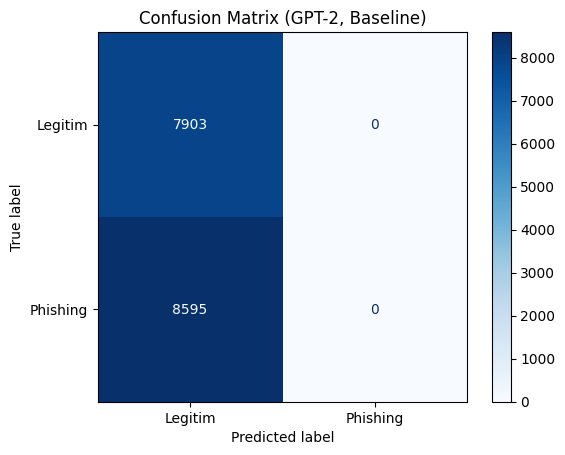

In [6]:
predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitim", "Phishing"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (GPT-2, Baseline)")
plt.show()